In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
import sys
import os
os.chdir("..")
print(os.getcwd())
sys.path.append(os.path.abspath(".."))

c:\Users\Administrator\Desktop\crop project\croprecommendationproject


In [2]:
from src.preprocessing import CropPreprocessor

preprocessor = CropPreprocessor()

data = preprocessor.preprocess("data/raw/Crop_recommendation.csv")

Cleaned dataset saved to: data/processed/cleaned_crop_data.csv


In [3]:
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [4]:
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred, average='weighted') * 100, 2) #weighted because we have multiple classes
    recall = round(recall_score(y_actual, y_pred, average='weighted')*100, 2)
    f1 = round(f1_score(y_actual, y_pred, average='weighted')*100, 2)
    confusionmatrix = confusion_matrix(y_actual,y_pred)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall, "F1":f1, "Confusion matrix":confusionmatrix.tolist()} #tolist()because i did not want the confusion matrix to be a numpy array and to have the data type

In [5]:

#hyperparameter tuning in order to find the best parameters for our random forest model, we will be using grid search cross validation to find the best parameters for our random forest model. 
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1_weighted')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

c:\ProgramData\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


CV F1 Score: 0.9943059367175289


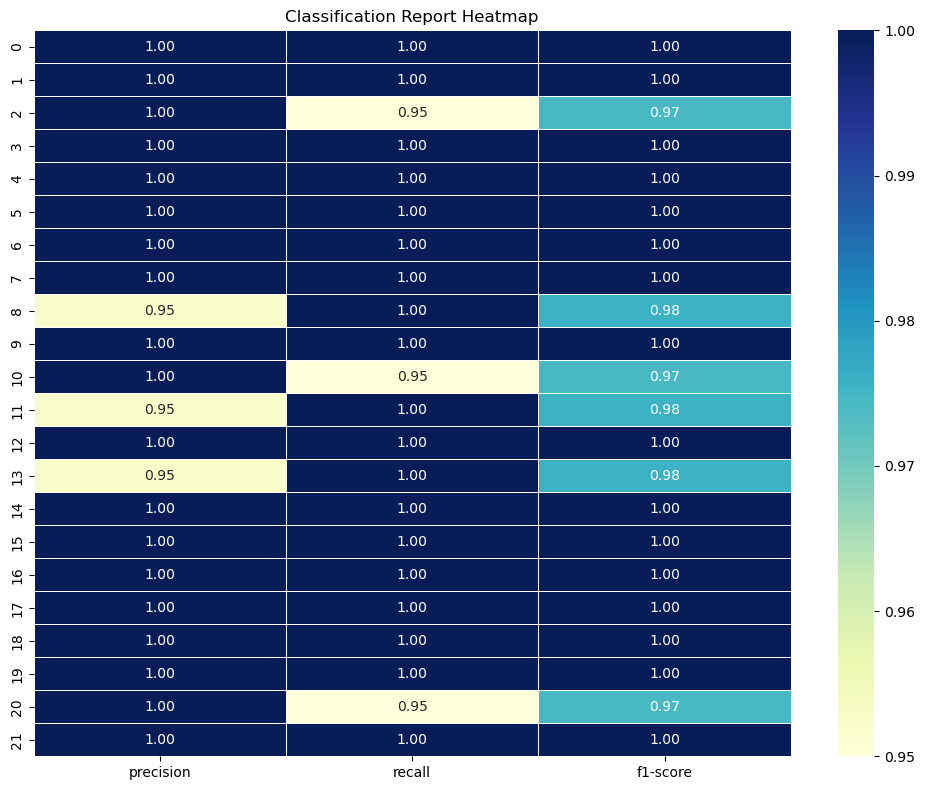

In [6]:
#evaluating the best model
rf = grid.best_estimator_
y_pred = rf.predict(X_test)
classification_metrics(y_test, y_pred)

scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted')
print("CV F1 Score:", scores.mean())

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# drop the averages rows if you want only per-class metrics
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    report_df[['precision', 'recall', 'f1-score']],  # drop support column
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title("Classification Report Heatmap")
plt.tight_layout()
plt.show()

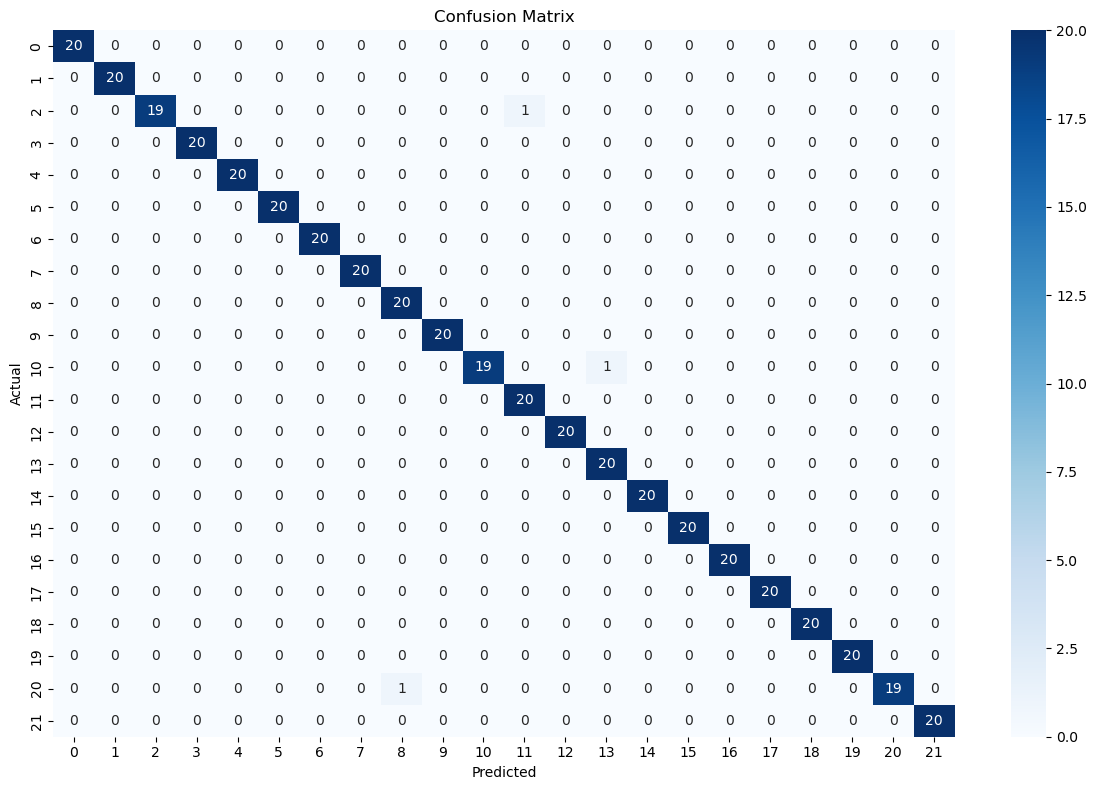

In [7]:
#virtualization of the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
#using OOB to train
rf_oob = RandomForestClassifier(**grid.best_params_, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print("OOB Score:", round(rf_oob.oob_score_ * 100, 2))

OOB Score: 99.49


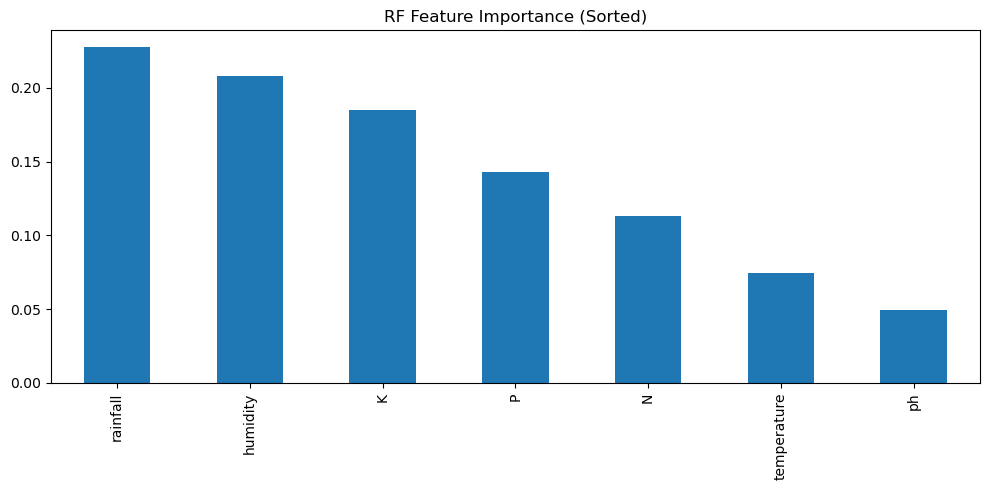

In [9]:
importances = pd.Series(rf.feature_importances_, index=data["feature_names"]).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar')
plt.title("RF Feature Importance (Sorted)")
plt.tight_layout()
plt.show()

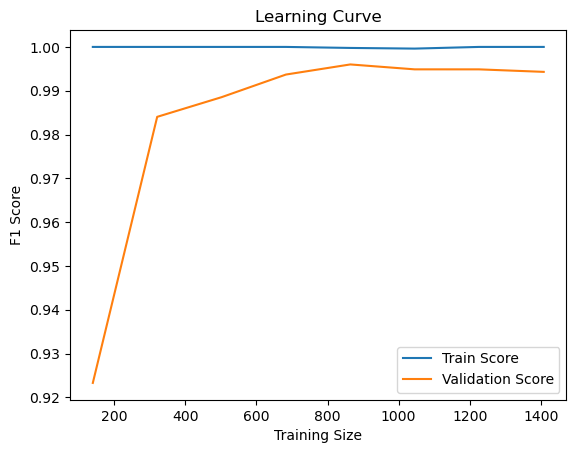

In [10]:
#learning curves


train_sizes, train_scores, val_scores = learning_curve(
    rf,
    data["X_train"],
    data["y_train"],
    cv=5, 
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [11]:


results = pd.DataFrame({
    "Actual": data["label_encoder"].inverse_transform(y_test),
    "Predicted": data["label_encoder"].inverse_transform(y_pred)
})

results["Correct"] = results["Actual"] == results["Predicted"]

results.to_csv("data/predictions/rf_predictions.csv", index=False)